## Scope
- [x] split the data into training, testing and validation set
- [x] Compare various models based on accuracy, precision, recall and F1

## Notebook 3: Comparing Machine Learning Models

After preparing and engineering the data, the next step is determining which machine learning algorithm is most effective at predicting customer churn.

In this notebook, I compare multiple classification models using several evaluation metrics.

The models are assessed using:

- Accuracy: Overall percentage of correct predictions.
- Precision: How often customers predicted to churn actually churn.
- Recall: How many actual churners the model successfully identifies.
- F1 Score: A balance between Precision and Recall.

Since churn datasets are often imbalanced (fewer churners than retained customers), relying on Accuracy alone can be misleading. Therefore, Recall and F1 Score are given significant importance.

The objective is to identify the model that best balances predictive performance with business usefulness.

By the end of this notebook, we have a clear understanding of which modelling approach performs best before moving to advanced techniques.

### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC # Support Vector Classifier
from xgboost import XGBClassifier # Requires xgboost library
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### Load the data

In [2]:
df = pd.read_excel('C:/Users/SMAHI/Downloads/archive/E Commerce Dataset.xlsx', sheet_name="E Comm")

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
df.shape

(5630, 20)

In [5]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [6]:
# Check for nulls
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

- So now the max null count any of the column has 307 which is 5.72% so removing these many columns will be fine but filling these if we can will be preferred

- All the columns which has null values are all numerical but categorical in some way so keeping that in mind, filling the nulls with median can be done

### Data cleaning

In [7]:
# Impute missing numerical values with median
cols_to_impute = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder'
]

In [8]:
for col in cols_to_impute:
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
# validate the filling of nulls
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [10]:
# Drop the col customer id because that is just an identifier and hold no significant value, infact it can bias the model
df.drop(columns=['CustomerID'], inplace=True)

In [11]:
# Check categories of the categorical value
df.nunique()

Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [12]:
# Change column names to lowercase
df.columns = [col.lower() for col in df.columns]
df.columns

Index(['churn', 'tenure', 'preferredlogindevice', 'citytier',
       'warehousetohome', 'preferredpaymentmode', 'gender', 'hourspendonapp',
       'numberofdeviceregistered', 'preferedordercat', 'satisfactionscore',
       'maritalstatus', 'numberofaddress', 'complain',
       'orderamounthikefromlastyear', 'couponused', 'ordercount',
       'daysincelastorder', 'cashbackamount'],
      dtype='object')

In [13]:
df.churn.value_counts()

0    4682
1     948
Name: churn, dtype: int64

**Stratified Split**: Since churn is a binary classification problem, it's important to maintain the proportion of churned and non-churned customers in both training and testing sets.

In [14]:
## Train test split
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


**Validation Set**: To fine-tune hyperparameters and prevent overfitting, consider splitting your training data further into training and validation sets.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)


In [16]:
df.head()

,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## One hot encoding

In [17]:
# One-hot encode relevant categorical columns for full correlation matrix
# For a full correlation matrix, you'd ideally one-hot encode all nominal categorical features.
# Let's pick a few for illustration:
categorical_cols_to_encode = ['preferredlogindevice', 'preferredpaymentmode', 'gender', 'maritalstatus', 'preferedordercat']
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True) # drop_first avoids multicollinearity for OHE


# Now, calculate the correlation matrix for the relevant columns including Churn
# Ensure all columns are numeric
numeric_df = df_encoded.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Get correlations with the 'Churn' column
churn_correlations = correlation_matrix['churn'].sort_values(ascending=False)
print("Correlations with Churn:\n", churn_correlations)

Correlations with Churn:
 churn                                    1.000000
complain                                 0.250188
maritalstatus_Single                     0.180847
preferedordercat_Mobile Phone            0.154387
preferedordercat_Mobile                  0.113364
numberofdeviceregistered                 0.107939
satisfactionscore                        0.105481
citytier                                 0.084703
preferredpaymentmode_COD                 0.083933
preferredlogindevice_Phone               0.078916
warehousetohome                          0.069544
preferredpaymentmode_E wallet            0.055751
numberofaddress                          0.043931
gender_Male                              0.029264
hourspendonapp                           0.018816
preferredpaymentmode_UPI                 0.004163
couponused                              -0.001430
preferredpaymentmode_Cash on Delivery   -0.006178
orderamounthikefromlastyear             -0.007075
ordercount              

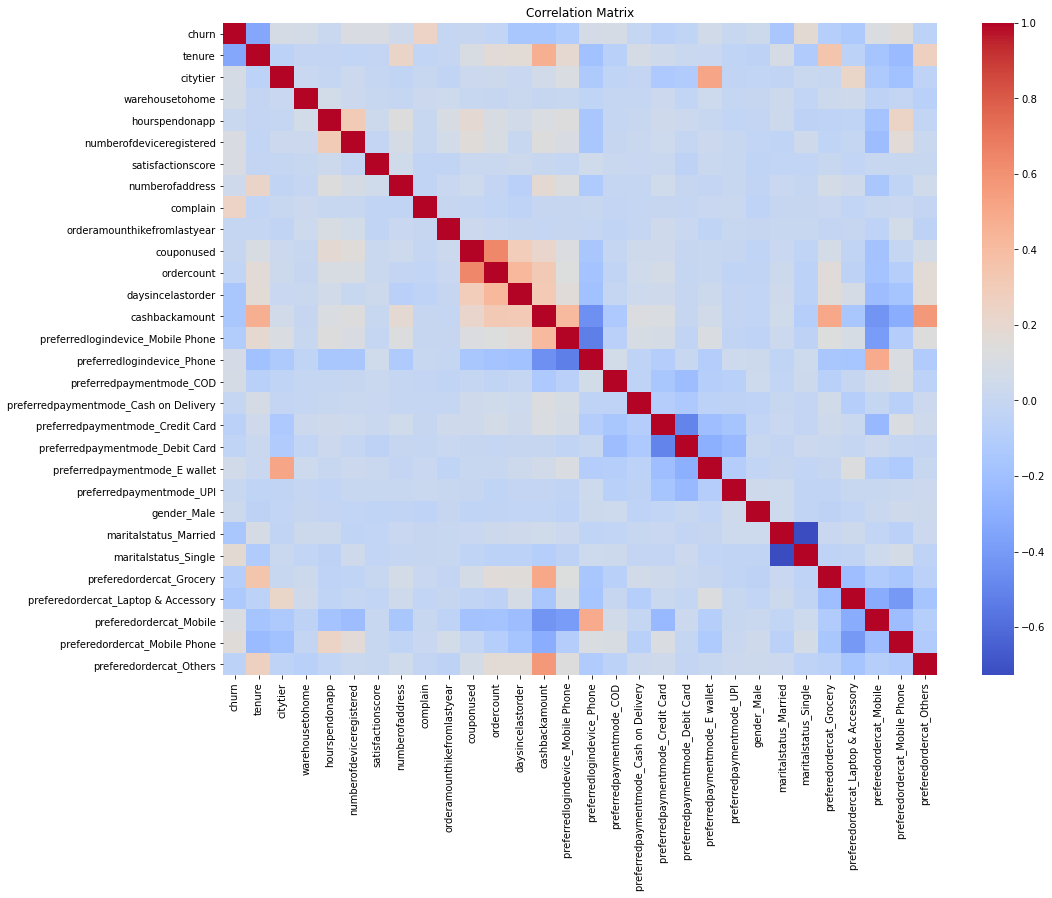

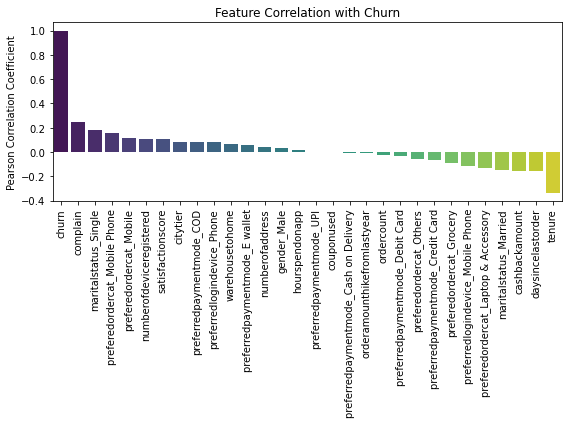

In [18]:
# Visualize the correlation matrix (heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# --- Specific Correlation with Churn (for important features) ---
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_correlations.index, y=churn_correlations.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Correlation with Churn')
plt.ylabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

Given that churn datasets are almost always imbalanced (fewer churners than non-churners), we'll implement a strategy to handle this. For most models, class_weight='balanced' is a good start, which adjusts the weights inversely proportional to class frequencies. For XGBoost, we'll use scale_pos_weight.

In [19]:
df.head()

,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [20]:
# --- 3. Define Features (X) and Target (y) ---
X = df.drop('churn', axis=1)
y = df['churn']
print(f"\nFeatures (X) shape: {X.shape}, Target (y) shape: {y.shape}")



Features (X) shape: (5630, 18), Target (y) shape: (5630,)


In [21]:
# --- 4. Identify Column Types for Preprocessing Pipeline ---
# This is crucial for applying different transformers to different column types.
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical columns identified: {numerical_cols}")
print(f"Categorical columns identified: {categorical_cols}")


Numerical columns identified: ['tenure', 'citytier', 'warehousetohome', 'hourspendonapp', 'numberofdeviceregistered', 'satisfactionscore', 'numberofaddress', 'complain', 'orderamounthikefromlastyear', 'couponused', 'ordercount', 'daysincelastorder', 'cashbackamount']
Categorical columns identified: ['preferredlogindevice', 'preferredpaymentmode', 'gender', 'preferedordercat', 'maritalstatus']


In [22]:
# --- 5. Create Preprocessing Pipeline ---
# Use ColumnTransformer to apply StandardScaler to numerical features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any, though none expected here)
)

In [23]:
# --- 6. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nData split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train value counts:\n{y_train.value_counts()}")
print(f"y_test value counts:\n{y_test.value_counts()}")



Data split into training and testing sets.
X_train shape: (4222, 18), X_test shape: (1408, 18)
y_train value counts:
0    3511
1     711
Name: churn, dtype: int64
y_test value counts:
0    1171
1     237
Name: churn, dtype: int64


In [24]:
# Calculate class weight for handling imbalance
# This is especially important for Logistic Regression, SVM, and can be used for Decision Trees/Random Forests
# (though XGBoost uses scale_pos_weight for a similar purpose).
class_counts = y_train.value_counts()
class_weight = {0: class_counts[0] / class_counts[1], 1: 1} # Weight for class 0 (No Churn) to balance class 1 (Churn)
# Or simply calculate: negative_samples / positive_samples
scale_pos_weight_value = class_counts[0] / class_counts[1]
print(f"\nCalculated class_weight for models: {class_weight}")
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_value:.2f}")


Calculated class_weight for models: {0: 4.938115330520394, 1: 1}
Calculated scale_pos_weight for XGBoost: 4.94


In [25]:
# --- 7. Define a Function to Train and Evaluate Models ---
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    print(f"\n--- Training {model_name} ---")
    
    # Create a pipeline that includes preprocessing and the model
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', model)])
    
    full_pipeline.fit(X_train, y_train)
    y_pred = full_pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"{model_name} Metrics:")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    
    # Print classification report for detailed view
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Optional: Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No Churn', 'Predicted Churn'],
                yticklabels=['Actual No Churn', 'Actual Churn'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


--- Training Logistic Regression ---
Logistic Regression Metrics:
  Accuracy : 0.8565
  Precision: 0.9070
  Recall   : 0.1646
  F1-Score : 0.2786

  Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1171
           1       0.91      0.16      0.28       237

    accuracy                           0.86      1408
   macro avg       0.88      0.58      0.60      1408
weighted avg       0.86      0.86      0.81      1408



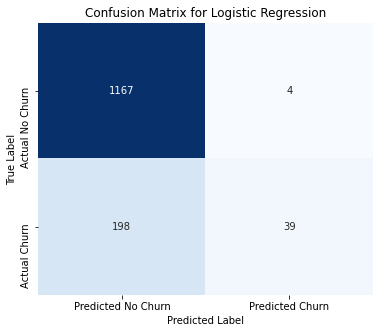


--- Training Decision Tree Classifier ---
Decision Tree Classifier Metrics:
  Accuracy : 0.9545
  Precision: 0.8531
  Recall   : 0.8819
  F1-Score : 0.8672

  Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1171
           1       0.85      0.88      0.87       237

    accuracy                           0.95      1408
   macro avg       0.91      0.93      0.92      1408
weighted avg       0.96      0.95      0.95      1408



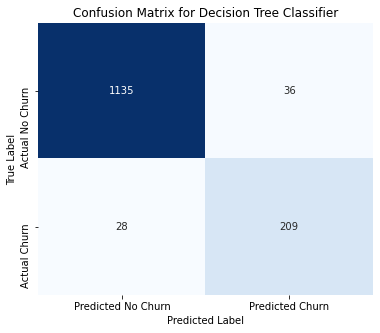


--- Training Random Forest Classifier ---
Random Forest Classifier Metrics:
  Accuracy : 0.9695
  Precision: 0.9533
  Recall   : 0.8608
  F1-Score : 0.9047

  Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1171
           1       0.95      0.86      0.90       237

    accuracy                           0.97      1408
   macro avg       0.96      0.93      0.94      1408
weighted avg       0.97      0.97      0.97      1408



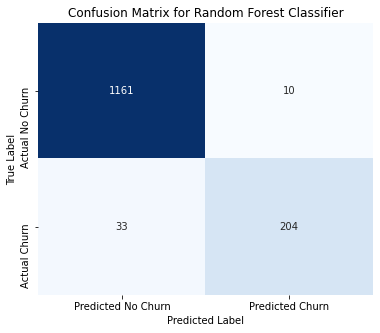


--- Training Gradient Boosting Classifier (sklearn) ---
Gradient Boosting Classifier (sklearn) Metrics:
  Accuracy : 0.9148
  Precision: 0.8197
  Recall   : 0.6329
  F1-Score : 0.7143

  Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1171
           1       0.82      0.63      0.71       237

    accuracy                           0.91      1408
   macro avg       0.87      0.80      0.83      1408
weighted avg       0.91      0.91      0.91      1408



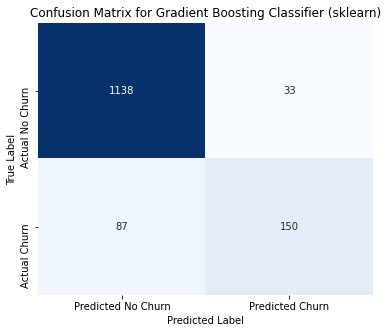


--- Training XGBoost Classifier ---


C:\Users\SMAHI\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:10:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Metrics:
  Accuracy : 0.9787
  Precision: 0.9331
  Recall   : 0.9409
  F1-Score : 0.9370

  Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1171
           1       0.93      0.94      0.94       237

    accuracy                           0.98      1408
   macro avg       0.96      0.96      0.96      1408
weighted avg       0.98      0.98      0.98      1408



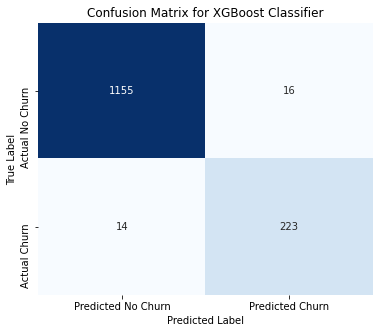


--- Training Support Vector Machine (SVC) ---
Support Vector Machine (SVC) Metrics:
  Accuracy : 0.9013
  Precision: 1.0000
  Recall   : 0.4135
  F1-Score : 0.5851

  Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1171
           1       1.00      0.41      0.59       237

    accuracy                           0.90      1408
   macro avg       0.95      0.71      0.76      1408
weighted avg       0.91      0.90      0.88      1408



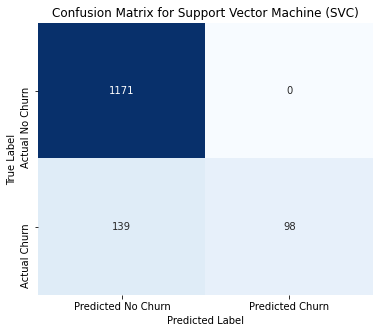

In [26]:
# --- 8. Train and Evaluate Each Model ---

results = []

# Logistic Regression
results.append(evaluate_model(
    "Logistic Regression",
    LogisticRegression(random_state=42, solver='liblinear', class_weight=class_weight),
    X_train, y_train, X_test, y_test
))

# Decision Tree Classifier
results.append(evaluate_model(
    "Decision Tree Classifier",
    DecisionTreeClassifier(random_state=42, class_weight=class_weight),
    X_train, y_train, X_test, y_test
))

# Random Forest Classifier
results.append(evaluate_model(
    "Random Forest Classifier",
    RandomForestClassifier(random_state=42, class_weight=class_weight, n_estimators=100),
    X_train, y_train, X_test, y_test
))

# Gradient Boosting Classifier (Scikit-learn's default GBC)
results.append(evaluate_model(
    "Gradient Boosting Classifier (sklearn)",
    GradientBoostingClassifier(random_state=42, n_estimators=100), # GBC doesn't have class_weight directly, but can be tuned for imbalance
    X_train, y_train, X_test, y_test
))

# XGBoost Classifier
# XGBoost handles class imbalance via scale_pos_weight, which is generally preferred for it.
results.append(evaluate_model(
    "XGBoost Classifier",
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                  scale_pos_weight=scale_pos_weight_value),
    X_train, y_train, X_test, y_test
))

# Support Vector Machine (SVC)
# Note: SVC can be very slow on large datasets without careful hyperparameter tuning.
results.append(evaluate_model(
    "Support Vector Machine (SVC)",
    SVC(random_state=42, class_weight=class_weight),
    X_train, y_train, X_test, y_test
))



             MODEL COMPARISON SUMMARY

Model: Logistic Regression
  Accuracy : 0.8565
  Precision: 0.9070
  Recall   : 0.1646
  F1-Score : 0.2786

Model: Decision Tree Classifier
  Accuracy : 0.9545
  Precision: 0.8531
  Recall   : 0.8819
  F1-Score : 0.8672

Model: Random Forest Classifier
  Accuracy : 0.9695
  Precision: 0.9533
  Recall   : 0.8608
  F1-Score : 0.9047

Model: Gradient Boosting Classifier (sklearn)
  Accuracy : 0.9148
  Precision: 0.8197
  Recall   : 0.6329
  F1-Score : 0.7143

Model: XGBoost Classifier
  Accuracy : 0.9787
  Precision: 0.9331
  Recall   : 0.9409
  F1-Score : 0.9370

Model: Support Vector Machine (SVC)
  Accuracy : 0.9013
  Precision: 1.0000
  Recall   : 0.4135
  F1-Score : 0.5851


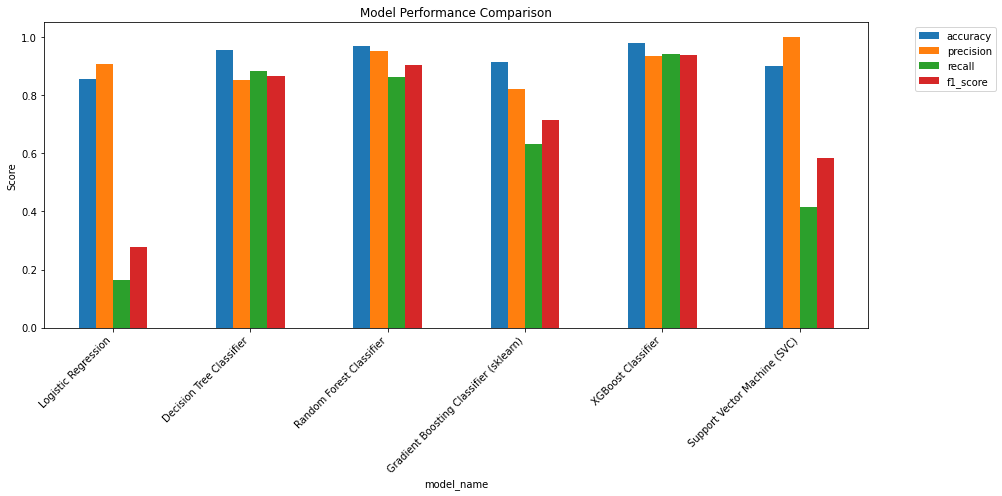

In [27]:
# --- 9. Summarize Results ---
print("\n" + "="*50)
print("             MODEL COMPARISON SUMMARY")
print("="*50)
for res in results:
    print(f"\nModel: {res['model_name']}")
    print(f"  Accuracy : {res['accuracy']:.4f}")
    print(f"  Precision: {res['precision']:.4f}")
    print(f"  Recall   : {res['recall']:.4f}")
    print(f"  F1-Score : {res['f1_score']:.4f}")
print("="*50)

# Optional: Visualize overall comparison
metrics_df = pd.DataFrame(results).set_index('model_name')
metrics_df.plot(kind='bar', figsize=(14, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Model Performance Evaluation

To identify the most effective churn prediction model, several machine learning algorithms were evaluated using four key metrics:

### Evaluation Metrics

**Accuracy**
Measures the percentage of total predictions that were correct.

**Precision**
Measures how often customers predicted to churn actually churned.

**Recall**
Measures how many of the actual churning customers were successfully identified by the model.

**F1 Score**
A balanced metric that combines Precision and Recall into a single score.

---

## Why Accuracy Alone Isn't Enough

In churn prediction, the goal is not simply to maximise overall prediction accuracy.

The real business objective is to identify customers who are likely to leave before they actually churn.

For example, if only 10 out of 100 customers churn, a model could predict that nobody will churn and still achieve 90% accuracy. While this may appear impressive, it would completely fail to identify customers at risk.

This is why **Recall** is particularly important for churn prediction projects.

Recall answers the question:

> "Of all customers who actually churned, how many did the model successfully identify?"

A higher Recall means the business has a greater opportunity to intervene and retain customers before they leave.

---

## Model Comparison

### Logistic Regression

Logistic Regression achieved a reasonable Accuracy (85.7%) and strong Precision (90.7%). However, its Recall was only 16.5%.

This means that the model successfully identified fewer than 17 out of every 100 customers who actually churned.

Although the model was cautious when predicting churn, it missed a large proportion of at-risk customers, making it less suitable for retention-focused business decisions.

---

### Decision Tree Classifier

The Decision Tree performed significantly better than Logistic Regression, achieving:

* Accuracy: 95.5%
* Recall: 88.2%
* F1 Score: 86.7%

The model was able to identify a large proportion of churning customers while maintaining strong overall performance.

---

### Random Forest Classifier

Random Forest delivered excellent results across all metrics:

* Accuracy: 96.9%
* Precision: 95.3%
* Recall: 86.1%
* F1 Score: 90.5%

The model demonstrated strong predictive power and would be a suitable candidate for deployment in a real-world retention strategy.

---

### Gradient Boosting Classifier

Gradient Boosting produced moderate performance:

* Accuracy: 91.5%
* Recall: 63.3%
* F1 Score: 71.4%

While it performed reasonably well, it was outperformed by both Random Forest and XGBoost.

---

### Support Vector Machine (SVM)

The Support Vector Machine achieved perfect Precision (100%), meaning every customer predicted to churn actually churned.

However, Recall was only 41.4%, indicating that the model failed to identify many customers who eventually churned.

For churn prediction, missing potential churners can be costly, making this model less practical despite its high Precision.

---

### Why XGBoost Was Selected

XGBoost achieved the best balance across every important metric:

* Highest Accuracy (97.9%)
* Very high Precision (93.3%)
* Highest Recall (94.1%)
* Highest F1 Score (93.7%)

This means:

Most churners were identified.
Few loyal customers were incorrectly flagged.
Overall predictions remained highly accurate.

For a retention team, this is exactly what you want.

If 100 customers are likely to churn:

XGBoost identifies approximately 94 of them.
Marketing teams can proactively target these customers with retention campaigns.
Fewer customers are missed compared with other models.

## Key Observation

An interesting finding from this comparison is that models with high Precision do not necessarily perform well in identifying churning customers.

For example:

* Logistic Regression achieved over 90% Precision but only 16.5% Recall.
* SVM achieved 100% Precision but only 41.4% Recall.

This highlights the importance of evaluating multiple performance metrics rather than relying on Accuracy or Precision alone.

For customer retention initiatives, identifying potential churners is often more valuable than making a small number of incorrect churn predictions.
